<a href="https://colab.research.google.com/github/ponzek/MNIST_ClassicalMLvsQML/blob/main/300QiskitSVM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Qiskit

In [ ]:
# ============================================
# CONNECT TO IBM QUANTUM WITH YOUR TOKEN
# ============================================

!pip3 install qiskit
!pip3 install qiskit-ibm-runtime


from qiskit_ibm_runtime import QiskitRuntimeService
from google.colab import userdata

# Get your token from Colab secrets
ibm_token = userdata.get('QISKIT_IBM_TOKEN')

# Connect to IBM Quantum
service = QiskitRuntimeService(
    channel="ibm_quantum_platform",
    token=ibm_token
)

# Test the connection
print("✅ Connected to IBM Quantum!")
print(f"📊 Available backends: {len(service.backends())}")

# Get the least busy real backend
backend = service.least_busy(operational=True, simulator=False)
print(f"🎯 Recommended backend: {backend.name}")

qiskit_runtime_service._discover_account:WARNING:2026-03-13 04:38:05,084: Loading account with the given token. A saved account will not be used.
qiskit_runtime_service.__init__:WARNING:2026-03-13 04:38:08,139: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-03-13 04:38:08,140: Loading instance: open-instance, plan: open


✅ Connected to IBM Quantum!
📊 Available backends: 3


qiskit_runtime_service.backends:WARNING:2026-03-13 04:38:09,393: Loading instance: open-instance, plan: open
qiskit_runtime_service.backends:WARNING:2026-03-13 04:38:10,435: Using instance: open-instance, plan: open


🎯 Recommended backend: ibm_fez


In [ ]:
# ============================================
# COMPLETE FIX - Run this ONCE
# ============================================

!pip uninstall qiskit-machine-learning qiskit-algorithms -y
!pip install qiskit-machine-learning==0.7.2 qiskit-algorithms==0.3.0 --quiet

print("✅ Versions fixed!")

# Test imports
from qiskit import QuantumCircuit
from qiskit.primitives import Sampler
from qiskit_algorithms.state_fidelities import ComputeUncompute
from qiskit_machine_learning.kernels import FidelityQuantumKernel
print("✅ All imports work!")

print("\n🎉 Ready to run Cell 7!")

Found existing installation: qiskit-machine-learning 0.8.0
Uninstalling qiskit-machine-learning-0.8.0:
  Successfully uninstalled qiskit-machine-learning-0.8.0
Found existing installation: qiskit-algorithms 0.3.0
Uninstalling qiskit-algorithms-0.3.0:
  Successfully uninstalled qiskit-algorithms-0.3.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.8/97.8 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 308.6/308.6 kB 17.6 MB/s eta 0:00:00
✅ Versions fixed!
✅ All imports work!

🎉 Ready to run Cell 7!


###Configuration A

In [ ]:
# ============================================
# CELL 7: QISKIT CONFIGURATION A (Basic H+RY, NO ZZ)
# 300 samples, 7 runs
# ============================================

import numpy as np
from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector
from qiskit.primitives import Sampler
from qiskit_algorithms.state_fidelities import ComputeUncompute
from qiskit_machine_learning.kernels import FidelityQuantumKernel
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score
import time
import pandas as pd
from scipy import stats
from datetime import datetime

print("="*60)
print("🔹 CELL 7: QISKIT CONFIG A (Basic H+RY, NO ZZ)")
print("300 samples, 7 runs")
print("="*60)

# Load MNIST
mnist = fetch_openml('mnist_784', version=1, as_frame=False)
X, y = mnist.data, mnist.target.astype(int)
mask = (y == 0) | (y == 1)
X, y = X[mask], y[mask]

# Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Store results
results_qiskit_basic = []

for run in range(7):
    print(f"\n🔷 Run {run+1}/7 (seed={42+run})")

    # Split data
    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y, test_size=0.3, random_state=42+run, stratify=y
    )

    # PCA to 2D
    pca = PCA(n_components=2)
    X_train_pca = pca.fit_transform(X_train)
    X_test_pca = pca.transform(X_test)

    # TAKE EXACTLY 300 SAMPLES
    X_train_300 = X_train_pca[:300]
    y_train_300 = y_train[:300]
    X_test_150 = X_test_pca[:150]
    y_test_150 = y_test[:150]

    print(f"   Train: {len(X_train_300)} samples, Test: {len(X_test_150)} samples")

    # BASIC CIRCUIT - NO ZZ
    params = ParameterVector('x', length=2)
    qc = QuantumCircuit(2)
    qc.h(0)
    qc.h(1)
    qc.ry(params[0], 0)
    qc.ry(params[1], 1)

    # Setup kernel
    sampler = Sampler()
    fidelity = ComputeUncompute(sampler=sampler)
    kernel = FidelityQuantumKernel(feature_map=qc, fidelity=fidelity)

    start_time = time.time()

    # Compute kernel matrices
    print("   Computing kernel matrices...")
    K_train = kernel.evaluate(X_train_300)
    K_test = kernel.evaluate(X_test_150, X_train_300)

    # Train QSVM
    qsvm = SVC(kernel='precomputed', probability=True)
    qsvm.fit(K_train, y_train_300)
    y_pred = qsvm.predict(K_test)
    y_score = qsvm.decision_function(K_test)
    y_score_norm = (y_score - y_score.min()) / (y_score.max() - y_score.min() + 1e-10)

    elapsed_time = time.time() - start_time

    # Store results
    results_qiskit_basic.append({
        'run': run+1,
        'framework': 'Qiskit',
        'circuit': 'Basic H+RY (NO ZZ)',
        'accuracy': accuracy_score(y_test_150, y_pred) * 100,
        'precision': precision_score(y_test_150, y_pred, average='binary'),
        'recall': recall_score(y_test_150, y_pred, average='binary'),
        'f1': f1_score(y_test_150, y_pred, average='binary'),
        'roc_auc': roc_auc_score(y_test_150, y_score_norm),
        'time': elapsed_time
    })

    print(f"   ✅ Run {run+1} complete: Acc={results_qiskit_basic[-1]['accuracy']:.1f}%, F1={results_qiskit_basic[-1]['f1']:.3f}, Time={elapsed_time:.1f}s")

# Save results
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
df = pd.DataFrame(results_qiskit_basic)
filename = f"qiskit_basic_NOzz_300_{timestamp}.csv"
df.to_csv(filename, index=False)

print(f"\n💾 Saved to {filename}")
print("\n✅ CELL 7 COMPLETE! Run CELL 8 next.")

🔹 CELL 7: QISKIT CONFIG A (Basic H+RY, NO ZZ)
300 samples, 7 runs

🔷 Run 1/7 (seed=42)
   Train: 300 samples, Test: 150 samples
   Computing kernel matrices...
   ✅ Run 1 complete: Acc=69.3%, F1=0.729, Time=73.5s

🔷 Run 2/7 (seed=43)
   Train: 300 samples, Test: 150 samples
   Computing kernel matrices...
   ✅ Run 2 complete: Acc=72.0%, F1=0.747, Time=68.8s

🔷 Run 3/7 (seed=44)
   Train: 300 samples, Test: 150 samples
   Computing kernel matrices...
   ✅ Run 3 complete: Acc=68.0%, F1=0.739, Time=68.5s

🔷 Run 4/7 (seed=45)
   Train: 300 samples, Test: 150 samples
   Computing kernel matrices...
   ✅ Run 4 complete: Acc=72.7%, F1=0.721, Time=67.5s

🔷 Run 5/7 (seed=46)
   Train: 300 samples, Test: 150 samples
   Computing kernel matrices...
   ✅ Run 5 complete: Acc=70.0%, F1=0.762, Time=66.7s

🔷 Run 6/7 (seed=47)
   Train: 300 samples, Test: 150 samples
   Computing kernel matrices...
   ✅ Run 6 complete: Acc=73.3%, F1=0.733, Time=68.7s

🔷 Run 7/7 (seed=48)
   Train: 300 samples, Test: 15

###Configuration B

In [ ]:
# ============================================
# CELL 8: QISKIT CONFIGURATION B (ZZFeatureMap, WITH ZZ)
# 300 samples, 7 runs
# ============================================

!pip install qiskit==0.46.3 qiskit-machine-learning==0.7.2 qiskit-algorithms==0.3.0 --quiet

import numpy as np
from qiskit.circuit.library import ZZFeatureMap
from qiskit.primitives import Sampler
from qiskit_algorithms.state_fidelities import ComputeUncompute
from qiskit_machine_learning.kernels import FidelityQuantumKernel
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score
import time
import pandas as pd
from scipy import stats
from datetime import datetime

print("="*60)
print("🔸 CELL 8: QISKIT CONFIG B (ZZFeatureMap, WITH ZZ)")
print("300 samples, 7 runs")
print("="*60)

# Load MNIST
mnist = fetch_openml('mnist_784', version=1, as_frame=False)
X, y = mnist.data, mnist.target.astype(int)
mask = (y == 0) | (y == 1)
X, y = X[mask], y[mask]

# Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Store results
results_qiskit_zz = []

for run in range(7):
    print(f"\n🔷 Run {run+1}/7 (seed={42+run})")

    # Split data
    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y, test_size=0.3, random_state=42+run, stratify=y
    )

    # PCA to 2D
    pca = PCA(n_components=2)
    X_train_pca = pca.fit_transform(X_train)
    X_test_pca = pca.transform(X_test)

    # TAKE EXACTLY 300 SAMPLES
    X_train_300 = X_train_pca[:300]
    y_train_300 = y_train[:300]
    X_test_150 = X_test_pca[:150]
    y_test_150 = y_test[:150]

    print(f"   Train: {len(X_train_300)} samples, Test: {len(X_test_150)} samples")

    # ZZFEATUREMAP CIRCUIT - WITH ZZ
    feature_map = ZZFeatureMap(feature_dimension=2, reps=2)

    # Setup kernel
    sampler = Sampler()
    fidelity = ComputeUncompute(sampler=sampler)
    kernel = FidelityQuantumKernel(feature_map=feature_map, fidelity=fidelity)

    start_time = time.time()

    # Compute kernel matrices
    print("   Computing kernel matrices...")
    K_train = kernel.evaluate(X_train_300)
    K_test = kernel.evaluate(X_test_150, X_train_300)

    # Train QSVM
    qsvm = SVC(kernel='precomputed', probability=True)
    qsvm.fit(K_train, y_train_300)
    y_pred = qsvm.predict(K_test)
    y_score = qsvm.decision_function(K_test)
    y_score_norm = (y_score - y_score.min()) / (y_score.max() - y_score.min() + 1e-10)

    elapsed_time = time.time() - start_time

    # Store results
    results_qiskit_zz.append({
        'run': run+1,
        'framework': 'Qiskit',
        'circuit': 'ZZFeatureMap (WITH ZZ)',
        'accuracy': accuracy_score(y_test_150, y_pred) * 100,
        'precision': precision_score(y_test_150, y_pred, average='binary'),
        'recall': recall_score(y_test_150, y_pred, average='binary'),
        'f1': f1_score(y_test_150, y_pred, average='binary'),
        'roc_auc': roc_auc_score(y_test_150, y_score_norm),
        'time': elapsed_time
    })

    print(f"   ✅ Run {run+1} complete: Acc={results_qiskit_zz[-1]['accuracy']:.1f}%, F1={results_qiskit_zz[-1]['f1']:.3f}, Time={elapsed_time:.1f}s")

# Save results
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
df = pd.DataFrame(results_qiskit_zz)
filename = f"qiskit_zz_WITHzz_300_{timestamp}.csv"
df.to_csv(filename, index=False)

print(f"\n💾 Saved to {filename}")
print("\n✅ CELL 8 COMPLETE! Run CELL 9 for graphs.")

🔸 CELL 8: QISKIT CONFIG B (ZZFeatureMap, WITH ZZ)
300 samples, 7 runs

🔷 Run 1/7 (seed=42)
   Train: 300 samples, Test: 150 samples
   Computing kernel matrices...
   ✅ Run 1 complete: Acc=54.7%, F1=0.595, Time=263.4s

🔷 Run 2/7 (seed=43)
   Train: 300 samples, Test: 150 samples
   Computing kernel matrices...
   ✅ Run 2 complete: Acc=44.7%, F1=0.520, Time=252.7s

🔷 Run 3/7 (seed=44)
   Train: 300 samples, Test: 150 samples
   Computing kernel matrices...
   ✅ Run 3 complete: Acc=54.0%, F1=0.663, Time=263.6s

🔷 Run 4/7 (seed=45)
   Train: 300 samples, Test: 150 samples
   Computing kernel matrices...
   ✅ Run 4 complete: Acc=46.0%, F1=0.537, Time=258.4s

🔷 Run 5/7 (seed=46)
   Train: 300 samples, Test: 150 samples
   Computing kernel matrices...
   ✅ Run 5 complete: Acc=54.0%, F1=0.627, Time=253.7s

🔷 Run 6/7 (seed=47)
   Train: 300 samples, Test: 150 samples
   Computing kernel matrices...
   ✅ Run 6 complete: Acc=50.7%, F1=0.580, Time=254.0s

🔷 Run 7/7 (seed=48)
   Train: 300 samples

###GRaphs between A & B

📊 CELL 9: QISKIT GRAPHS - Config A vs Config B

📁 Config A (Basic): qiskit_basic_NOzz_300_20260313_095316.csv
📁 Config B (ZZ): qiskit_zz_WITHzz_300_20260313_102443.csv


/tmp/ipykernel_72118/4154114802.py:166: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax7.boxplot(data_to_plot, labels=['Basic', 'ZZ'], patch_artist=True)


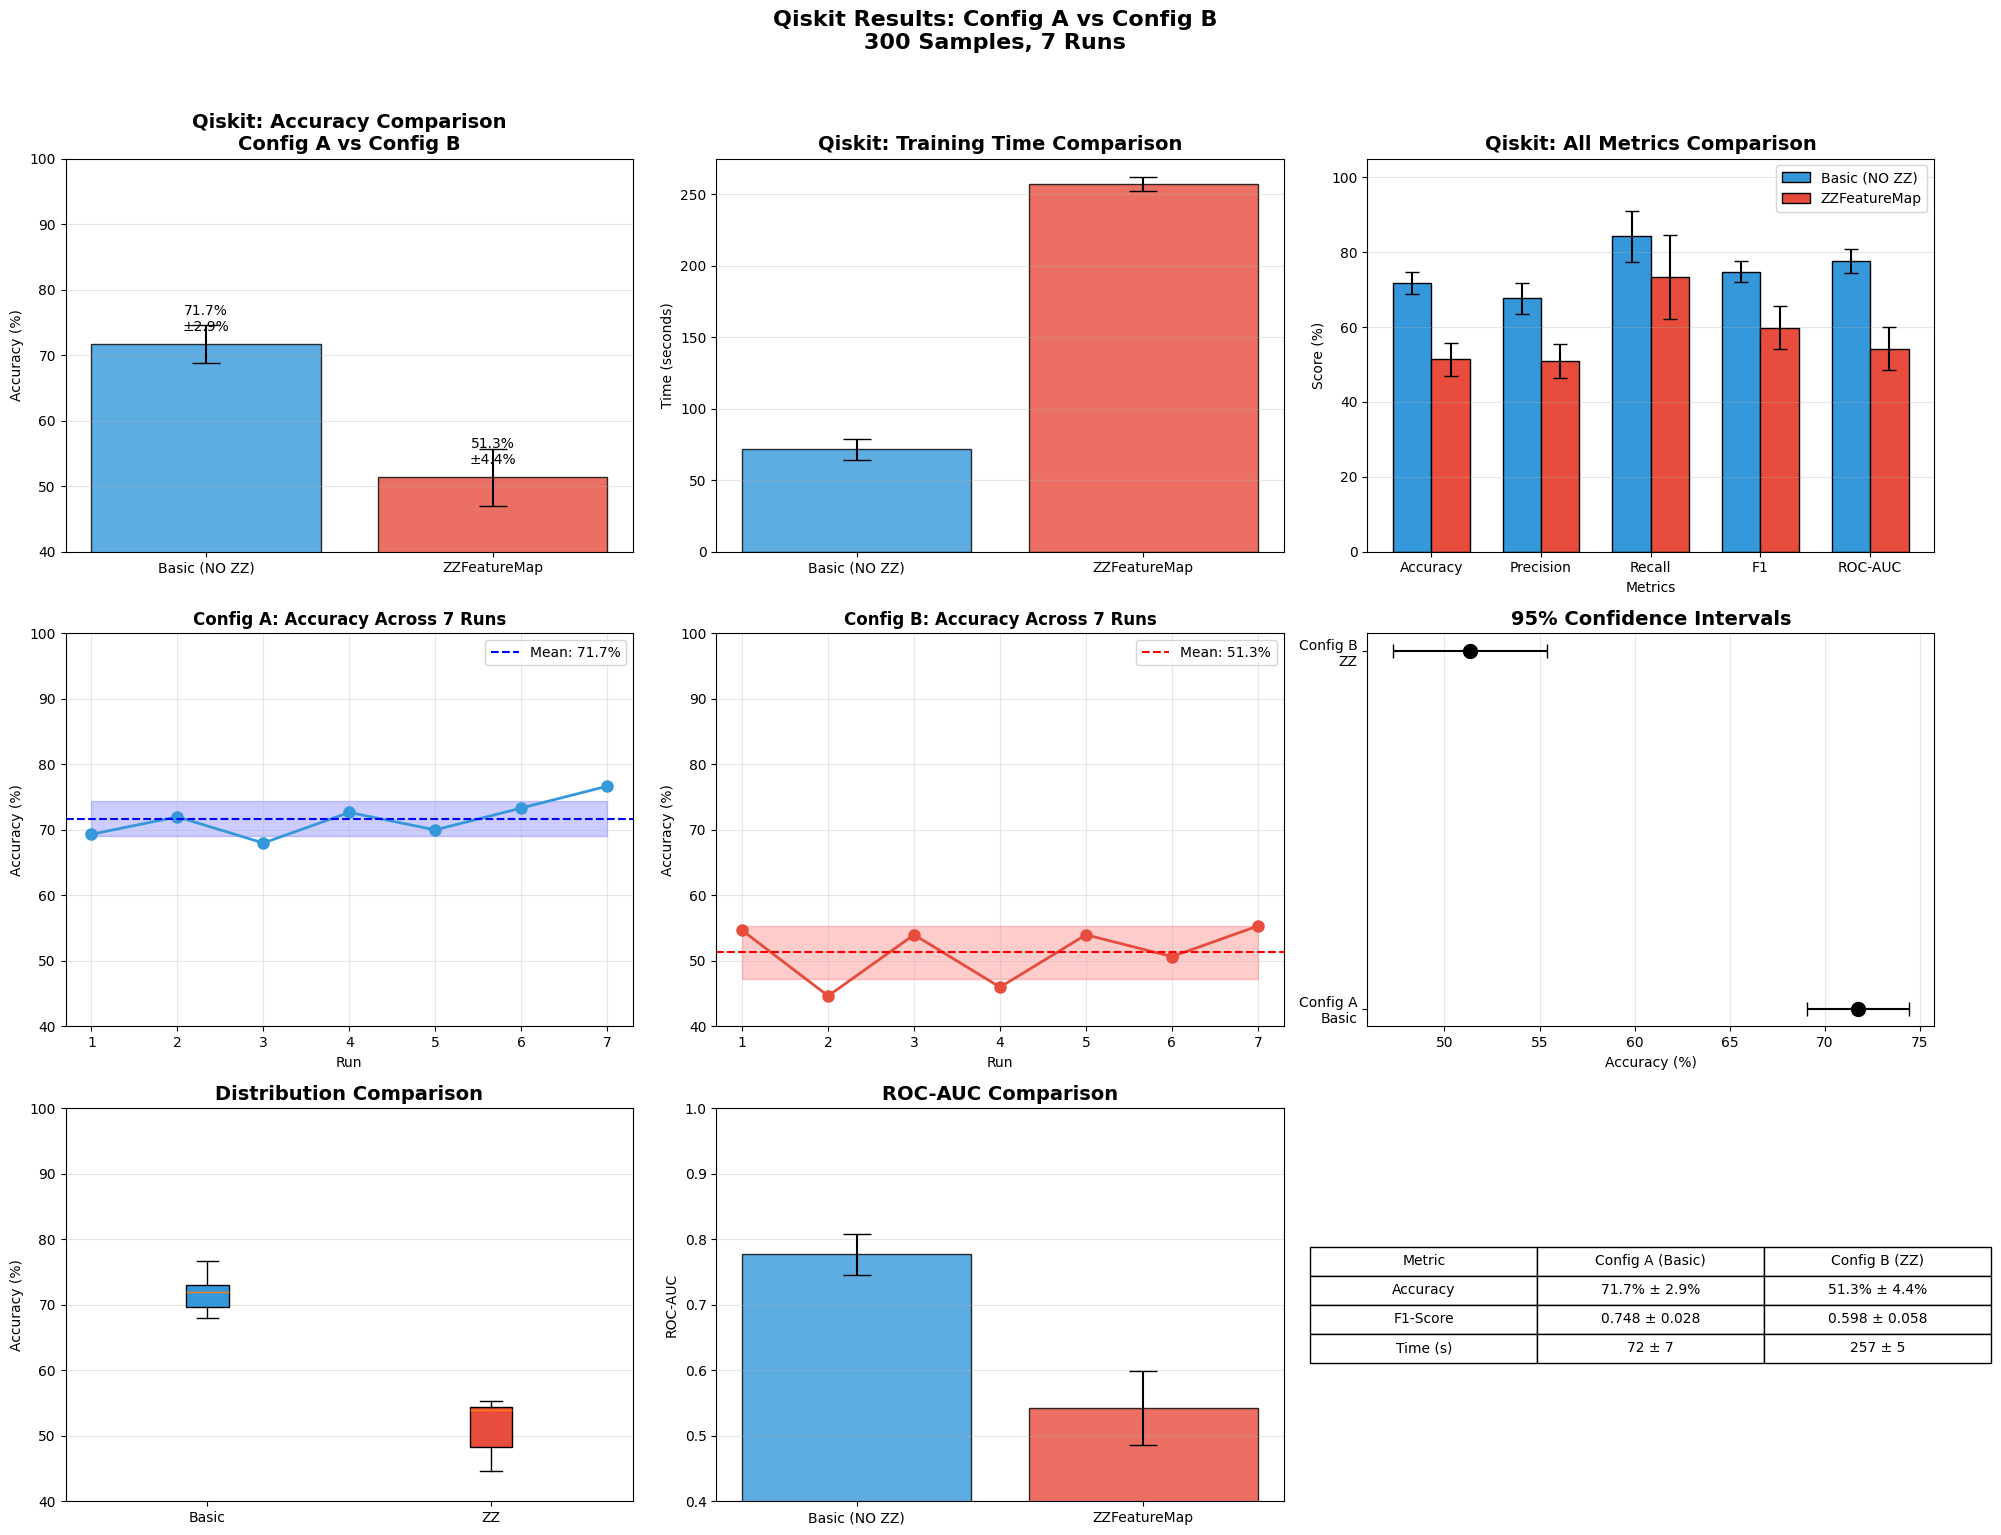


✅ Graphs saved as 'qiskit_configA_vs_configB_results.png'


In [ ]:
# ============================================
# CELL 9: QISKIT GRAPHS - Config A vs Config B
# Run this after Cells 7 and 8 complete
# ============================================

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
import glob

print("="*60)
print("📊 CELL 9: QISKIT GRAPHS - Config A vs Config B")
print("="*60)

# Find Qiskit result files
basic_files = glob.glob('qiskit_basic_NOzz_300_*.csv')
zz_files = glob.glob('qiskit_zz_WITHzz_300_*.csv')

if not basic_files or not zz_files:
    print("❌ Missing results! Run Cells 7 and 8 first.")
else:
    latest_basic = sorted(basic_files)[-1]
    latest_zz = sorted(zz_files)[-1]

    print(f"\n📁 Config A (Basic): {latest_basic}")
    print(f"📁 Config B (ZZ): {latest_zz}")

    df_basic = pd.read_csv(latest_basic)
    df_zz = pd.read_csv(latest_zz)

    # Create figure with subplots
    fig = plt.figure(figsize=(20, 15))

    # Graph 1: Accuracy Comparison
    ax1 = plt.subplot(3, 3, 1)
    configs = ['Basic (NO ZZ)', 'ZZFeatureMap']
    means = [df_basic['accuracy'].mean(), df_zz['accuracy'].mean()]
    stds = [df_basic['accuracy'].std(), df_zz['accuracy'].std()]

    bars = ax1.bar(configs, means, yerr=stds, capsize=10,
                   color=['#3498db', '#e74c3c'], edgecolor='black', linewidth=1, alpha=0.8)
    ax1.set_ylabel('Accuracy (%)')
    ax1.set_title('Qiskit: Accuracy Comparison\nConfig A vs Config B', fontsize=14, fontweight='bold')
    ax1.set_ylim(40, 100)
    ax1.grid(True, alpha=0.3, axis='y')

    # Add value labels
    for bar, mean, std in zip(bars, means, stds):
        ax1.text(bar.get_x() + bar.get_width()/2., mean + 2,
                f'{mean:.1f}%\n±{std:.1f}%', ha='center', fontsize=10)

    # Graph 2: Time Comparison
    ax2 = plt.subplot(3, 3, 2)
    time_means = [df_basic['time'].mean(), df_zz['time'].mean()]
    time_stds = [df_basic['time'].std(), df_zz['time'].std()]

    bars = ax2.bar(configs, time_means, yerr=time_stds, capsize=10,
                   color=['#3498db', '#e74c3c'], edgecolor='black', linewidth=1, alpha=0.8)
    ax2.set_ylabel('Time (seconds)')
    ax2.set_title('Qiskit: Training Time Comparison', fontsize=14, fontweight='bold')
    ax2.grid(True, alpha=0.3, axis='y')

    # Graph 3: All Metrics Comparison
    ax3 = plt.subplot(3, 3, 3)
    metrics = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']
    x = np.arange(len(metrics))
    width = 0.35

    basic_metrics = [df_basic['accuracy'].mean(),
                     df_basic['precision'].mean()*100,
                     df_basic['recall'].mean()*100,
                     df_basic['f1'].mean()*100,
                     df_basic['roc_auc'].mean()*100]

    zz_metrics = [df_zz['accuracy'].mean(),
                  df_zz['precision'].mean()*100,
                  df_zz['recall'].mean()*100,
                  df_zz['f1'].mean()*100,
                  df_zz['roc_auc'].mean()*100]

    basic_stds = [df_basic['accuracy'].std(),
                  df_basic['precision'].std()*100,
                  df_basic['recall'].std()*100,
                  df_basic['f1'].std()*100,
                  df_basic['roc_auc'].std()*100]

    zz_stds = [df_zz['accuracy'].std(),
               df_zz['precision'].std()*100,
               df_zz['recall'].std()*100,
               df_zz['f1'].std()*100,
               df_zz['roc_auc'].std()*100]

    ax3.bar(x - width/2, basic_metrics, width, yerr=basic_stds,
            label='Basic (NO ZZ)', color='#3498db', capsize=5, edgecolor='black')
    ax3.bar(x + width/2, zz_metrics, width, yerr=zz_stds,
            label='ZZFeatureMap', color='#e74c3c', capsize=5, edgecolor='black')

    ax3.set_xlabel('Metrics')
    ax3.set_ylabel('Score (%)')
    ax3.set_title('Qiskit: All Metrics Comparison', fontsize=14, fontweight='bold')
    ax3.set_xticks(x)
    ax3.set_xticklabels(metrics)
    ax3.set_ylim(0, 105)
    ax3.legend()
    ax3.grid(True, alpha=0.3, axis='y')

    # Graph 4: Accuracy across runs (Config A)
    ax4 = plt.subplot(3, 3, 4)
    runs = df_basic['run'].values
    acc_basic = df_basic['accuracy'].values

    ax4.plot(runs, acc_basic, 'o-', color='#3498db', linewidth=2, markersize=8)
    ax4.axhline(y=acc_basic.mean(), color='blue', linestyle='--', label=f"Mean: {acc_basic.mean():.1f}%")
    ax4.fill_between(runs, acc_basic.mean() - acc_basic.std(),
                     acc_basic.mean() + acc_basic.std(), alpha=0.2, color='blue')
    ax4.set_xlabel('Run')
    ax4.set_ylabel('Accuracy (%)')
    ax4.set_title('Config A: Accuracy Across 7 Runs', fontsize=12, fontweight='bold')
    ax4.set_xticks(runs)
    ax4.set_ylim(40, 100)
    ax4.legend()
    ax4.grid(True, alpha=0.3)

    # Graph 5: Accuracy across runs (Config B)
    ax5 = plt.subplot(3, 3, 5)
    acc_zz = df_zz['accuracy'].values

    ax5.plot(runs, acc_zz, 'o-', color='#e74c3c', linewidth=2, markersize=8)
    ax5.axhline(y=acc_zz.mean(), color='red', linestyle='--', label=f"Mean: {acc_zz.mean():.1f}%")
    ax5.fill_between(runs, acc_zz.mean() - acc_zz.std(),
                     acc_zz.mean() + acc_zz.std(), alpha=0.2, color='red')
    ax5.set_xlabel('Run')
    ax5.set_ylabel('Accuracy (%)')
    ax5.set_title('Config B: Accuracy Across 7 Runs', fontsize=12, fontweight='bold')
    ax5.set_xticks(runs)
    ax5.set_ylim(40, 100)
    ax5.legend()
    ax5.grid(True, alpha=0.3)

    # Graph 6: 95% Confidence Intervals
    ax6 = plt.subplot(3, 3, 6)

    ci_basic = stats.t.interval(0.95, len(acc_basic)-1,
                                loc=acc_basic.mean(), scale=stats.sem(acc_basic))
    ci_zz = stats.t.interval(0.95, len(acc_zz)-1,
                             loc=acc_zz.mean(), scale=stats.sem(acc_zz))

    y_pos = [0, 1]
    means_ci = [acc_basic.mean(), acc_zz.mean()]
    ci_low = [means_ci[0] - ci_basic[0], means_ci[1] - ci_zz[0]]
    ci_high = [ci_basic[1] - means_ci[0], ci_zz[1] - means_ci[1]]

    ax6.errorbar(means_ci, y_pos, xerr=[ci_low, ci_high],
                 fmt='o', color='black', capsize=5, markersize=10)
    ax6.set_yticks(y_pos)
    ax6.set_yticklabels(['Config A\nBasic', 'Config B\nZZ'])
    ax6.set_xlabel('Accuracy (%)')
    ax6.set_title('95% Confidence Intervals', fontsize=14, fontweight='bold')
    ax6.grid(True, alpha=0.3, axis='x')

    # Graph 7: Box Plot Comparison
    ax7 = plt.subplot(3, 3, 7)

    data_to_plot = [df_basic['accuracy'], df_zz['accuracy']]
    bp = ax7.boxplot(data_to_plot, labels=['Basic', 'ZZ'], patch_artist=True)
    bp['boxes'][0].set_facecolor('#3498db')
    bp['boxes'][1].set_facecolor('#e74c3c')

    ax7.set_ylabel('Accuracy (%)')
    ax7.set_title('Distribution Comparison', fontsize=14, fontweight='bold')
    ax7.set_ylim(40, 100)
    ax7.grid(True, alpha=0.3, axis='y')

    # Graph 8: ROC-AUC Comparison
    ax8 = plt.subplot(3, 3, 8)

    roc_means = [df_basic['roc_auc'].mean(), df_zz['roc_auc'].mean()]
    roc_stds = [df_basic['roc_auc'].std(), df_zz['roc_auc'].std()]

    bars = ax8.bar(configs, roc_means, yerr=roc_stds, capsize=10,
                   color=['#3498db', '#e74c3c'], edgecolor='black', linewidth=1, alpha=0.8)
    ax8.set_ylabel('ROC-AUC')
    ax8.set_title('ROC-AUC Comparison', fontsize=14, fontweight='bold')
    ax8.set_ylim(0.4, 1.0)
    ax8.grid(True, alpha=0.3, axis='y')

    # Graph 9: Summary Table
    ax9 = plt.subplot(3, 3, 9)
    ax9.axis('tight')
    ax9.axis('off')

    summary_data = [
        ['Metric', 'Config A (Basic)', 'Config B (ZZ)'],
        ['Accuracy', f"{df_basic['accuracy'].mean():.1f}% ± {df_basic['accuracy'].std():.1f}%",
                    f"{df_zz['accuracy'].mean():.1f}% ± {df_zz['accuracy'].std():.1f}%"],
        ['F1-Score', f"{df_basic['f1'].mean():.3f} ± {df_basic['f1'].std():.3f}",
                    f"{df_zz['f1'].mean():.3f} ± {df_zz['f1'].std():.3f}"],
        ['Time (s)', f"{df_basic['time'].mean():.0f} ± {df_basic['time'].std():.0f}",
                    f"{df_zz['time'].mean():.0f} ± {df_zz['time'].std():.0f}"]
    ]

    table = ax9.table(cellText=summary_data, loc='center', cellLoc='center')
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1.2, 1.5)

    plt.suptitle('Qiskit Results: Config A vs Config B\n300 Samples, 7 Runs',
                 fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig('qiskit_configA_vs_configB_results.png', dpi=150, bbox_inches='tight')
    plt.show()

    print("\n✅ Graphs saved as 'qiskit_configA_vs_configB_results.png'")